# Grids of SNEC models
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [5]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser, plot_vel_radius_at_time_t, plot_mass_radius, plot_v_radius_time, get_times
import astropy.units as u
import glob
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def sorter(folder):
    return float(folder.split("_e_")[-1].rstrip("/").replace("d", "e"))

In [11]:
root = "/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/"
models = sorted(glob.glob(root+"*/"), key=sorter)
print(models)
print(len(models))

['/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_-10.d45/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_-1d46/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_-1d44/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_-1d43/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d45/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d46/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d47/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d48/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d49/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d50/', '/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d51/']
12


/home/mrenzo/Runs/SNEC_grid/30Msun_VdJNL/bomb_final_e_1.0d51/


0


1


2


3


...

8


9


10


11


12


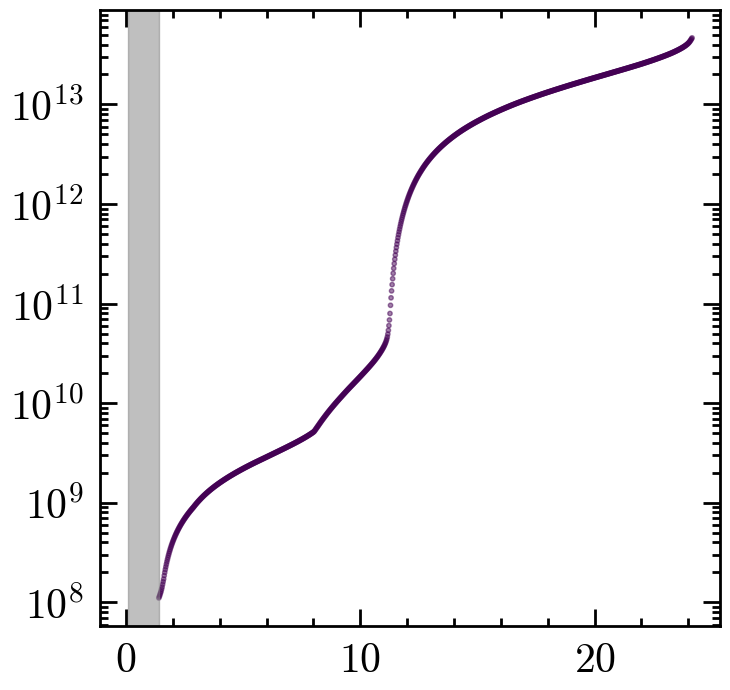

In [39]:
fig = plt.figure()
gs = gridspec.GridSpec(120, 120)
ax = fig.add_subplot(gs[:, :])

bomb_spread = 0.1 *u.Msun # see parameters file

for j, m in enumerate([models[-1]]):
    print(m)
    outfile = m+'/Data/mass.xg'
    times = get_times(outfile)
    # times = [times[0], times[int(len(times)/2.)], times[-1]]
    for i, t in enumerate(times[::100]):
        print(i)
        m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, s=10*(1+i))
        xmin = min(m.to(u.Msun))
ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
# ax.set_xlim(xmin.value, 2.0)
ax.set_yscale('log')

[0.00000000e+00 3.65591088e+03 7.34174877e+03 ... 4.31294175e+06
 4.31654175e+06 4.32000000e+06] s [0.00000000e+00 2.96248923e+37 2.96248923e+37 ... 2.96248923e+37
 2.96248923e+37 2.96248923e+37] erg / s


/tmp/ipykernel_1310764/3718344014.py:11: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(t.to(u.d), np.log10(L.value), **kwargs)


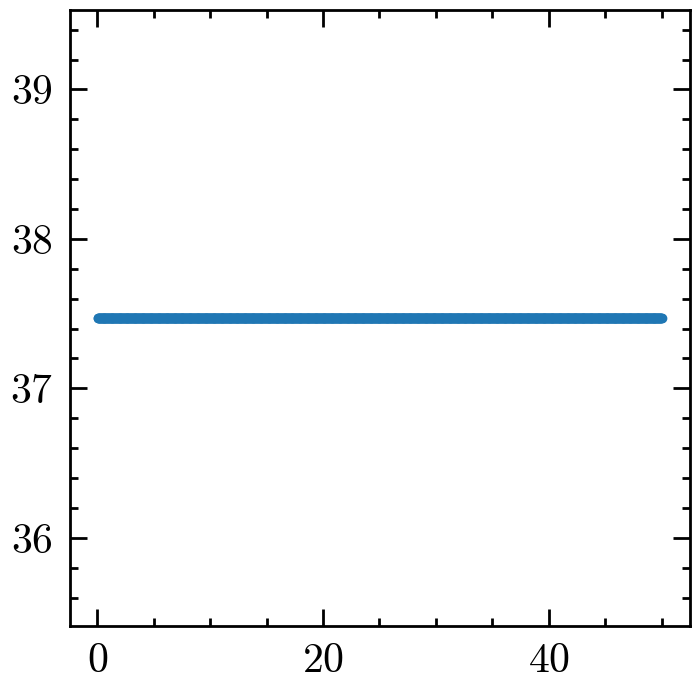

In [43]:
def plot_LC(folder, ax=None, **kwargs):
    obs_lum = folder+'Data/lum_observed.dat'
    src = np.genfromtxt(obs_lum)
    t = src[:, 0] * u.s
    L = src[:,1] * u.erg/u.s
    if not ax:
        fig = plt.figure()
        gs = gridspec.GridSpec(100, 100)
        ax = fig.add_subplot(gs[:, :])
    ax.scatter(t.to(u.d), np.log10(L.value), **kwargs)
    # ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

plot_LC(models[-1], ax=ax)
